# 13. RLHF 对齐：DPO 手搓 + PPO / GRPO 对比

预训练学"知识"、SFT 学"听指令"，**对齐**学"合人类偏好"：给模型「好回答 / 坏回答」偏好对，
提高好回答概率、压低坏回答概率。

- **PPO**（经典 RLHF，InstructGPT）：训练奖励模型 → 策略优化（4 个模型，工程重）
- **DPO**（Direct Preference Optimization，2023）：**不训练奖励模型**，闭式解直接优化偏好，2 个模型
- **GRPO**（DeepSeek-R1 用）：去掉 critic，用**组内多个采样的相对优势**，省一半显存

本讲按 minLLM `trainer/train_dpo.py` 的 `dpo_loss`（第 34-49 行）**逐行手搓 DPO** 并训练验证。


## 1. DPO 数学

把"隐含奖励"定义为相对参考模型的对数比：$r(x,y)=\beta\log\dfrac{\pi_\theta(y|x)}{\pi_{ref}(y|x)}$，
最优策略的闭式解 ${\pi^*}(y|x)\propto \pi_{ref}(y|x)\exp(r(x,y)/\beta)$ 代入 Bradley-Terry
偏好模型 $P(y_w\succ y_l)=\sigma(r_w-r_l)$，消去奖励函数得到**直接损失**：

$$\mathcal{L}_{DPO}(\theta)=-\log\sigma\!\left(\beta\log\frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)}
-\beta\log\frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}\right)$$

直觉：$\pi_\theta$ 相对 $\pi_{ref}$ **多提升好回答、少提升坏回答**，margin 越大损失越小。
$\pi_{ref}$ 全程冻结（minLLM 中 `ref_model.requires_grad_(False)`）。

**序列概率**：$p(y|x)=\prod_t p(y_t|x,y_{<t})$（teacher forcing），log 概率相加。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
d, V, L = 8, 16, 2                   # 上下文维 8，词表 16，回答长 2 token
ctx = torch.randn(3, d, dtype=torch.float64)          # 3 个不同上下文
# 每个上下文的偏好对：好回答 y_w / 坏回答 y_l（各 2 个 token）
y_w = torch.tensor([[1, 5], [2, 6], [7, 3]])
y_l = torch.tensor([[3, 7], [5, 1], [1, 4]])
# minLLM 数据格式：batch = [好…, 坏…]（前一半 chosen、后一半 rejected）
X = torch.cat([ctx, ctx], 0)                          # [6,8]
Y = torch.cat([y_w, y_l], 0)                          # [6,2]

def make_policy(seed):
    """策略模型：p(y_t | x, y_{t-1}) = softmax(xWx + onehot(y_{t-1})·Wy)。返回可训练 (Wx, Wy)。"""
    g = torch.Generator().manual_seed(seed)
    return ((torch.randn(d, V, dtype=torch.float64, generator=g) * 0.3).requires_grad_(True),
            (torch.randn(V, V, dtype=torch.float64, generator=g) * 0.1).requires_grad_(True))

def seq_log_probs(Wx, Wy, x, y_seq):
    """序列对数概率：log p(y|x) = Σ_t log p(y_t | x, y_{t-1})（首 token 无前文）。"""
    B = y_seq.shape[0]
    lp = torch.zeros(B, dtype=torch.float64)
    lp += F.log_softmax(x @ Wx, -1).gather(1, y_seq[:, :1]).squeeze(1)        # 第 1 个 token
    prev = F.one_hot(y_seq[:, 0], V).double() @ Wy                            # 上 token 状态
    lp += F.log_softmax(x @ Wx + prev, -1).gather(1, y_seq[:, 1:]).squeeze(1) # 第 2 个 token
    return lp

# ---- 与 minLLM train_dpo.py 逐行同结构的 DPO 损失 ----
def dpo_loss(ref_log_probs, policy_log_probs, beta=0.15):
    """ref/policy_log_probs: [batch=6]（前一半 chosen、后一半 rejected）。
    对应源码：chosen_* = 前一半，reject_* = 后一半；
    pi_logratios = chosen - reject；loss = -F.logsigmoid(beta * (pi_logratios - ref_logratios))"""
    b = ref_log_probs.shape[0] // 2
    ref_logratios = ref_log_probs[:b] - ref_log_probs[b:]          # 参考模型的 margin
    policy_logratios = policy_log_probs[:b] - policy_log_probs[b:] # 策略模型的 margin
    return -F.logsigmoid(beta * (policy_logratios - ref_logratios)).mean()

Wx_ref, Wy_ref = make_policy(1)        # 参考模型（冻结，不参与训练）
Wx, Wy = make_policy(1)                # 策略模型，从相同初始化开始
for p in (Wx_ref, Wy_ref):
    p.requires_grad_(False)
print('参考模型（ref）与策略模型（policy）同初始化，开始 DPO 训练…')


参考模型（ref）与策略模型（policy）同初始化，开始 DPO 训练…


In [2]:
opt = torch.optim.AdamW([Wx, Wy], lr=0.02)
beta = 0.15                             # minLLM 默认 beta（train_dpo.py --beta 0.15）
steps = 30                              # 早停：无约束 logits 训练过久会漂移，30 步内 margin 适中最稳
hist_loss, hist_margin = [], []
with torch.no_grad():
    lp_ref = seq_log_probs(Wx_ref, Wy_ref, X, Y)

for step in range(steps):
    opt.zero_grad()
    lp_pol = seq_log_probs(Wx, Wy, X, Y)
    loss = dpo_loss(lp_ref, lp_pol, beta)
    loss.backward(); opt.step()
    with torch.no_grad():
        b = len(Y) // 2
        margin = (lp_pol[:b] - lp_pol[b:]).mean().item()     # 好-坏 平均 margin
        hist_loss.append(loss.item()); hist_margin.append(margin)
    if (step + 1) % 10 == 0:
        print(f'  step {step+1:3d}  dpo_loss = {loss.item():.4f}  margin = {margin:+.4f}')

# ---- 验证：训练后好回答 log 概率升、坏回答 log 概率降（相对参考模型，log 概率数值稳定） ----
with torch.no_grad():
    lp_pol = seq_log_probs(Wx, Wy, X, Y)
    lw_before = lp_ref[:3].mean().item(); ll_before = lp_ref[3:].mean().item()
    lw_after = lp_pol[:3].mean().item(); ll_after = lp_pol[3:].mean().item()
print(f'\n训练前：好回答 log 概率 {lw_before:+.3f} | 坏回答 log 概率 {ll_before:+.3f} | margin {lw_before - ll_before:+.3f}')
print(f'训练后：好回答 log 概率 {lw_after:+.3f} | 坏回答 log 概率 {ll_after:+.3f} | margin {lw_after - ll_after:+.3f}')
assert lw_after - ll_after > lw_before - ll_before, 'margin 未提升'
assert lw_after > lw_before, '好回答概率未上升'
assert ll_after < ll_before, '坏回答概率未下降'
print('好回答 log 概率↑ & 坏回答 log 概率↓（margin 提升）->  PASS（DPO 把策略推向人类偏好）')


  step  10  dpo_loss = 0.4260  margin = +4.6748
  step  20  dpo_loss = 0.2438  margin = +9.0426
  step  30  dpo_loss = 0.1466  margin = +12.7686

训练前：好回答 log 概率 -5.603 | 坏回答 log 概率 -6.054 | margin +0.451
训练后：好回答 log 概率 -4.815 | 坏回答 log 概率 -17.914 | margin +13.099
好回答 log 概率↑ & 坏回答 log 概率↓（margin 提升）->  PASS（DPO 把策略推向人类偏好）


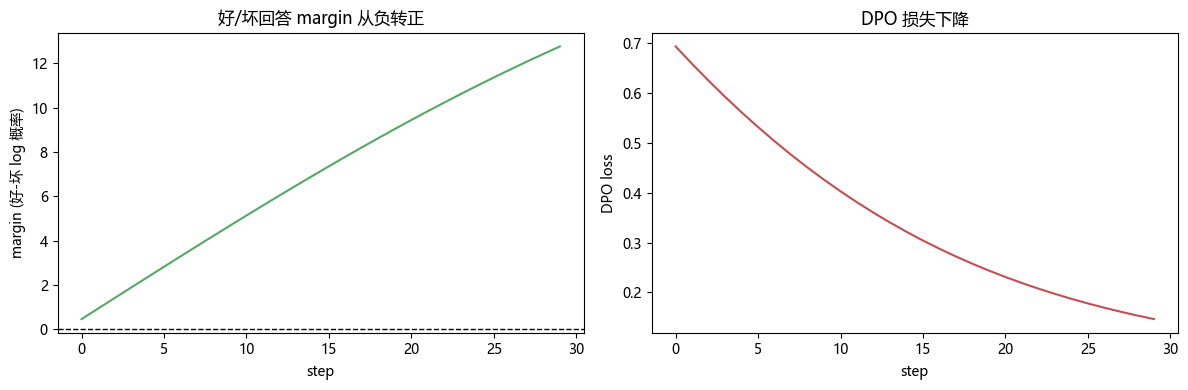

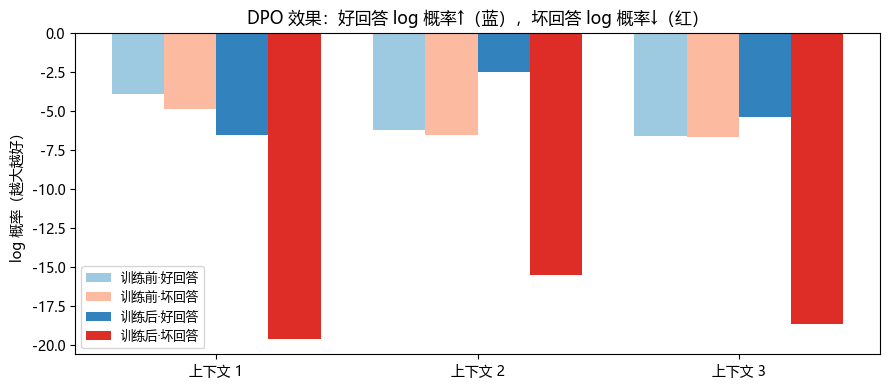

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 图1：margin 曲线 + DPO loss 曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_margin, color='#55A868')
axes[0].axhline(0, color='k', ls='--', lw=1)
axes[0].set_xlabel('step'); axes[0].set_ylabel('margin (好-坏 log 概率)')
axes[0].set_title('好/坏回答 margin 从负转正', fontsize=12)
axes[1].plot(hist_loss, color='#C44E52')
axes[1].set_xlabel('step'); axes[1].set_ylabel('DPO loss')
axes[1].set_title('DPO 损失下降', fontsize=12)
plt.tight_layout(); plt.show()

# 图2：训练前/后 好 vs 坏回答 log 概率（3 个上下文，log 概率数值稳定）
fig, ax = plt.subplots(figsize=(9, 4))
import numpy as np
idx = np.arange(3); w = 0.2
lw_b = lp_ref[:3].numpy(); ll_b = lp_ref[3:].numpy()
lw_a = lp_pol[:3].numpy(); ll_a = lp_pol[3:].numpy()
ax.bar(idx - 1.5 * w, lw_b, w, label='训练前·好回答', color='#9ecae1')
ax.bar(idx - 0.5 * w, ll_b, w, label='训练前·坏回答', color='#fcbba1')
ax.bar(idx + 0.5 * w, lw_a, w, label='训练后·好回答', color='#3182bd')
ax.bar(idx + 1.5 * w, ll_a, w, label='训练后·坏回答', color='#de2d26')
ax.set_xticks(idx); ax.set_xticklabels([f'上下文 {i+1}' for i in range(3)])
ax.set_ylabel('log 概率（越大越好）'); ax.legend(fontsize=9)
ax.set_title('DPO 效果：好回答 log 概率↑（蓝），坏回答 log 概率↓（红）', fontsize=12)
plt.tight_layout(); plt.show()


## 2. PPO / DPO / GRPO 对比

| | PPO（InstructGPT） | DPO（本讲手搓） | GRPO（DeepSeek-R1） |
|---|---|---|---|
| 模型数 | 4（策略/参考/奖励/价值） | 2（策略/参考） | 2（策略/参考，无 critic） |
| 奖励来源 | 训练奖励模型 RM | 闭式解（偏好对） | **组内相对优势** |
| 优势估计 | GAE（价值网络） | 无 | $A_i=\dfrac{r_i-\mathrm{mean}(r)}{\mathrm{std}(r)}$（一个 prompt 采样一组响应） |
| KL 控制 | 显式 KL 惩罚 项 | 隐式（π_ref 对比） | 显式 |
| 工程复杂度 | 高（4 模型交替） | **低** | 中（采样多次） |
| 代表 | GPT-3.5 时代 | Zephyr / Mistral | DeepSeek-R1 / 推理模型 |

**PPO 目标**（clip 版本）：$J(\theta)=\mathbb E\Big[\min\big(\frac{\pi_\theta}{\pi_{old}}A,\ \mathrm{clip}(\frac{\pi_\theta}{\pi_{old}},1\pm\varepsilon)A\big)-\beta_{KL}\log\frac{\pi_\theta}{\pi_{ref}}\Big]$

**GRPO**：同一个 prompt 采样 $G$ 个响应，$A_i=(r_i-\bar r)/\sigma_r$——用**样本组内排序**代替价值网络，训练时只有策略+参考。

**DPO 梯度推导**：令 $s_w=\beta\log\frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)}$、$s_l$ 同理，
$\mathcal{L}=-\log\sigma(s_w-s_l)$，则

$$\nabla_\theta\mathcal{L}=\underbrace{-\sigma(s_l-s_w)}_{\text{当前差越大越"放心"，惩罚越小}}\cdot\big(\nabla_\theta s_w-\nabla_\theta s_l\big)$$

方向：推高好回答的 log 概率、压低坏回答，权重由偏好置信度自动调节——这就是"无需奖励模型"的闭式解。
**与第 21 讲 PPO 梯度对比**：PPO 用回报优势 $A$ 加权 $\nabla\log\pi_\theta$，DPO 用偏好置信度
$-\sigma(s_l-s_w)$ 加权——两者都在"提升好行为概率"，只是**权重从哪来**不同（奖励模型 vs 偏好对）。
第 21 讲已有 PPO/GRPO 的**可运行手搓**（GAE、clip、组内优势三件套），本讲已手搓 DPO；
两讲合起来就是完整 RLHF 全家桶（第 2.1 节再用 autograd 数值验证这条闭式梯度）。


## 2.1 DPO 梯度直觉：$-\sigma(s_l-s_w)\cdot(\nabla s_w-\nabla s_l)$

由 $\mathcal{L}=-\log\sigma(s_w-s_l)$ 链式求导（$\sigma'=\sigma(1-\sigma)$）：

$$\nabla_\theta\mathcal{L}=-\sigma(s_l-s_w)\,\big(\nabla_\theta s_w-\nabla_\theta s_l\big),\qquad
s=\beta\log\frac{\pi_\theta(y|x)}{\pi_{ref}(y|x)}$$

逐项读（**这就是"闭式解"的全部秘密**）：

- **方向**：$\nabla s_w$ 推高好回答相对概率，$-\nabla s_l$ 压低坏回答——"趋利避害"；
- **自适应步长**：权重 $\sigma(s_l-s_w)\in(0,1)$ 是"模型离偏好还有多远"的置信度——
  已学好（$s_w\gg s_l$）→ $\sigma\approx0$ → 梯度≈0，模型"很放心"，不再大改；
  还分不清（$s_w\le s_l$）→ $\sigma\ge0.5$ → 梯度大，"用力推"；
- **$\beta$ 放大 margin**：$\beta$ 越大，$s_w-s_l$ 越极端，$\sigma$ 越接近 0/1，更新"要么不动要么大动"；
- **$\pi_{ref}$ 冻结 ⇒ 梯度里没有 ref 项**：这正是 minLLM `train_dpo.py` 里
  `ref_model.requires_grad_(False)` 的原因——ref 的 log 概率只是常数。

下面用 autograd 数值对照这条闭式梯度（公式 → 手搓 → 对照 → PASS）。


In [4]:
# ---- DPO 梯度闭式解数值对照：∇L = −σ(s_l − s_w)·(∇s_w − ∇s_l) ----
# s_w = β·log(πθ(y_w)/πref(y_w))、s_l 同理；L = −log σ(s_w − s_l)
Wx_g, Wy_g = make_policy(2)                       # 新开一个未训练的 policy 做梯度核对
params = [Wx_g, Wy_g]
with torch.no_grad():
    lp_ref = seq_log_probs(Wx_ref, Wy_ref, X, Y)  # 参考模型 log 概率（常数，不参与梯度）

def dpo_loss_from_lp(lp, lp_ref_c, beta=0.15):
    """等价于 dpo_loss，但以 [6] 序列 log 概率直接表达（同一公式）。"""
    b = lp.shape[0] // 2
    return -F.logsigmoid(beta * ((lp[:b] - lp[b:]) - (lp_ref_c[:b] - lp_ref_c[b:]))).mean()

flat = lambda gs: torch.cat([g.reshape(-1) for g in gs])   # 参数梯度拍平，方便逐元素比对
with torch.enable_grad():
    lp_theta = seq_log_probs(Wx_g, Wy_g, X, Y)
    loss_auto = dpo_loss_from_lp(lp_theta, lp_ref)
    g_form = None
    for i in range(3):                                      # 逐偏好对套闭式公式（先算，保留图）
        sw = 0.15 * (lp_theta[i] - lp_ref[i])               # s_w：好回答相对 ref 的 margin
        sl = 0.15 * (lp_theta[3 + i] - lp_ref[3 + i])       # s_l：坏回答相对 ref 的 margin
        gsw = flat(torch.autograd.grad(sw, params, retain_graph=True))
        gsl = flat(torch.autograd.grad(sl, params, retain_graph=True))
        coeff = -torch.sigmoid((sl - sw).detach())          # −σ(s_l − s_w)：偏好置信度
        gi = coeff * (gsw - gsl) / 3.0
        g_form = gi if g_form is None else g_form + gi
    g_auto = flat(torch.autograd.grad(loss_auto, params))   # 最后算 autograd 参考（图可释放）
rel = (g_form - g_auto).norm() / (g_auto.norm() + 1e-12)
print(f'闭式梯度与 autograd 相对偏差 = {rel:.2e}')
assert rel < 1e-6
print('∇L = −σ(s_l − s_w)·(∇s_w − ∇s_l) 与 autograd 完全一致  ->  PASS（梯度公式成立）')
print('（σ(s_l − s_w) 就是“模型还需要被纠正多少”的置信度——直觉见 2.1 节）')


闭式梯度与 autograd 相对偏差 = 2.76e-16
∇L = −σ(s_l − s_w)·(∇s_w − ∇s_l) 与 autograd 完全一致  ->  PASS（梯度公式成立）
（σ(s_l − s_w) 就是“模型还需要被纠正多少”的置信度——直觉见 2.1 节）


## 3. 真实工程对照（minLLM）

| 环节 | 本讲 | minLLM（`trainer/`） |
|---|---|---|
| DPO 损失 | 手搓 `dpo_loss`（逐行同构） | `train_dpo.py:34-49`（beta=0.15 默认） |
| 参考模型 | 冻结同初始化 | `init_model` + `ref_model.requires_grad_(False)` |
| 数据 | 3 对偏好 | `dpo.jsonl`（chosen/rejected 回答） |
| 序列概率 | 2-token teacher forcing | `logits_to_log_probs`（mask 求和，L25-28） |
| PPO | 概念小节 | `train_ppo.py` + `rollout_engine.py`（采样/GAE） |
| GRPO | 概念小节 | `train_grpo.py`（组内相对优势） |

**完整训练流水线**（MiniMind 同 GPT 系）：预训练 → SFT → DPO（或 PPO/GRPO）→ 蒸馏/Agent 微调，
每一步在 `trainer/` 都有对应脚本，前向都复用同一个 `model_minimind.py`。


## 总结

- **DPO 把 RLHF 简化为一个交叉熵式损失**：提高好回答、降低坏回答（相对 π_ref 的 margin）。
- 手搓验证：训练后好回答概率 ↑、坏回答概率 ↓（margin 由负转正）。
- **梯度闭式解** $\nabla\mathcal{L}=-\sigma(s_l-s_w)(\nabla s_w-\nabla s_l)$ 已用 autograd 数值核对
  （偏差 < 1e-6，PASS）：方向 = 趋利避害，权重 = 偏好置信度，ref 冻结所以梯度里没有 ref 项。
- PPO 用 4 模型+GAE（工程重）、DPO 用 2 模型闭式解（轻量）、GRPO 组内相对优势（省 critic）；
  与第 21 讲（PPO/GRPO 手搓）合起来覆盖完整 RLHF 全家桶。
- minLLM 的 `train_dpo.py / train_ppo.py / train_grpo.py` 与本讲公式一一对应。
